In [4]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 模拟读取数据 (请替换为您实际的读取代码)
# 假设您的数据是 CSV 格式
# ==========================================
download_df = pd.read_csv('data/download.txt',     sep='\t',header=None)
playback_df = pd.read_csv('data/playback.txt',     sep='\t',header=None)

# 为了演示，这里生成模拟数据 (模拟图片中的字段)
np.random.seed(42)
num_records = 100000

# ==========================================
# 2. 数据预处理与关联 (按照图片中的 Logic 和 Limitation)
# ==========================================

# 2.1 统计原始日志规模
print("=== 原始日志规模 ===")
print(f"下载日志原始记录数: {len(download_df)}")
print(f"播放日志原始记录数: {len(playback_df)}")

# 2.2 截取 10 分钟的数据 (图片中 Experiment: 10 minutes joint data source)
# 假设以播放日志的最早时间为基准，向后推10分钟 (600,000 毫秒)
start_time = playback_df['client_time'].min()
end_time = start_time + 10 * 60 * 1000

playback_10min = playback_df[(playback_df['client_time'] >= start_time) & (playback_df['client_time'] <= end_time)]
download_10min = download_df[(download_df['client_time'] >= start_time) & (download_df['client_time'] <= end_time)]

# 2.3 计算吞吐量 (按照图片中的 Calculation 公式)
# 注意：图片中 Flow size 是求和，但实际单条日志通常直接计算 size/duration
# 这里我们按照字段直接计算单条下载记录的吞吐量
download_10min['Throughput_Mbps'] = (download_10min['client_download_size'] * 8) / (download_10min['network_cost'] / 1000) / 1e6

# 2.4 执行 Join (按照 request_id 进行内连接)
# 图片 Limitation: Cause further sampling (only matched "request_id" entry will be kept)
joint_df = pd.merge(
    playback_10min,
    download_10min[['request_id', 'Throughput_Mbps', 'client_download_size', 'network_cost']],
    on='request_id',
    how='inner', # 只保留匹配上的记录
    suffixes=('_playback', '_download')
)


# ==========================================
# 3. 统计联合数据集的规模 (类似 KuaiRand 的描述格式)
# ==========================================
print("\n=== 10分钟联合数据源 (Joint Data Source) 规模统计 ===")

# 统计去重后的用户数 (通过 client_ip 或 client_device 统计，因为图片中 user_id 未明确给出)
unique_users = joint_df['client_ip'].nunique() 
# 统计去重后的视频数/请求数 (通过 request_id 统计)
unique_requests = joint_df['request_id'].nunique()
# 统计总交互记录数
total_records = len(joint_df)

# 统计其他特征
avg_throughput = joint_df['Throughput_Mbps'].mean()
total_rebuffer_count = joint_df['block_count'].sum()

print(f"该数据集由 {unique_users} 个用户（基于client_ip去重）、{unique_requests} 个视频请求、{total_records} 条联合交互记录组成。")
print(f"数据特征：平均吞吐量为 {avg_throughput:.2f} Mbps，总卡顿次数为 {total_rebuffer_count} 次。")

# 打印前5行看看结果
print("\n=== 合并后的数据预览 (Joint) ===")
print(joint_df[['request_id', 'network_type_playback', 'block_count', 'Throughput_Mbps']].head())

=== 原始日志规模 ===
下载日志原始记录数: 12047324
播放日志原始记录数: 2973802


KeyError: 'client_time'

用户观看行为基本统计
有效样本数: 2905799
平均观看时长: 24.81 s
中位数观看时长: 12.60 s
P25: 3.56 s
P75: 36.09 s
最小值: 0.00 s
最大值: 24370.31 s
平均观看比例: 57.42%
中位数观看比例: 66.81%


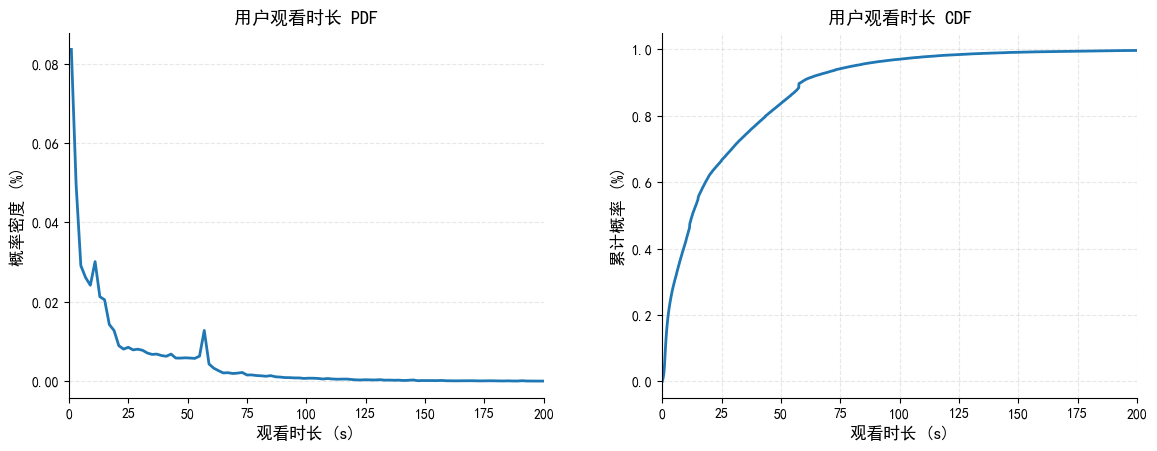

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 中文字体
# ============================================================

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 读取 Playback 数据
# ============================================================

file_path = 'data/playback.txt'

# 根据你给出的示例，数据使用 \t 分隔
playback = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)


# ============================================================
# 提取字段
# ============================================================

# 第4列：视频时长（ms）
video_duration = pd.to_numeric(
    playback.iloc[:, 3],
    errors='coerce'
)

# 第5列：实际观看时长（ms）
playback_duration = pd.to_numeric(
    playback.iloc[:, 4],
    errors='coerce'
)


# ============================================================
# 数据清洗
# ============================================================

data = pd.DataFrame({
    'video_duration': video_duration,
    'playback_duration': playback_duration
})

# 删除缺失值
data = data.dropna()

# 去除异常值
data = data[
    (data['video_duration'] > 0) &
    (data['playback_duration'] > 0)
]

# 实际观看时间不应该明显超过视频时长
# data = data[
#     data['playback_duration'] <= data['video_duration']
# ]
data['playback_duration'] = np.minimum(
    data['playback_duration'],
    data['video_duration']
)


# ============================================================
# 转换为秒
# ============================================================

data['video_duration_s'] = (
    data['video_duration'] / 1000
)

data['playback_duration_s'] = (
    data['playback_duration'] / 1000
)


# ============================================================
# 计算观看比例
# ============================================================

data['view_ratio'] = (
    data['playback_duration']
    / data['video_duration']
)


# ============================================================
# 输出基本统计信息
# ============================================================

print('==============================')
print('用户观看行为基本统计')
print('==============================')

print(f'有效样本数: {len(data)}')

print(
    f"平均观看时长: "
    f"{data['playback_duration_s'].mean():.2f} s"
)

print(
    f"中位数观看时长: "
    f"{data['playback_duration_s'].median():.2f} s"
)

print(
    f"P25: "
    f"{data['playback_duration_s'].quantile(0.25):.2f} s"
)

print(
    f"P75: "
    f"{data['playback_duration_s'].quantile(0.75):.2f} s"
)

print(
    f"最小值: "
    f"{data['playback_duration_s'].min():.2f} s"
)

print(
    f"最大值: "
    f"{data['playback_duration_s'].max():.2f} s"
)

print(
    f"平均观看比例: "
    f"{data['view_ratio'].mean() * 100:.2f}%"
)

print(
    f"中位数观看比例: "
    f"{data['view_ratio'].median() * 100:.2f}%"
)

# ============================================================
# 观看时长数据
# ============================================================

duration = data['playback_duration_s'].values

# 排序
duration_sorted = np.sort(duration)

# CDF
cdf = np.arange(
    1,
    len(duration_sorted) + 1
) / len(duration_sorted)


# ============================================================
# PDF
# ============================================================

# 使用直方图估计 PDF
# log_dur = np.log10(duration[duration > 0])
# 
# 
# pdf, bins = np.histogram(
#     log_dur,
#     bins=200,
#     density=True
# )

start, stop = duration.min(), duration.max()
bins = np.arange(start, stop + 2, 2)   # 从 start 起，步长 2
pdf, edges = np.histogram(duration, bins=bins, density=True)

bin_centers = (
    bins[:-1] + bins[1:]
) / 2

# ============================================================
# 创建图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ============================================================
# 左图：PDF
# ============================================================

axes[0].plot(
    bin_centers,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)
axes[0].set_xlim(0, 200)

axes[0].set_ylabel(
    '概率密度 (%)',
    fontsize=12
)

axes[0].set_title(
    '用户观看时长 PDF',
    fontsize=13
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ============================================================
# 右图：CDF
# ============================================================

axes[1].plot(
    duration_sorted,
    cdf,
    linewidth=2
)

axes[1].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)
axes[1].set_xlim(0, 200)

axes[1].set_ylabel(
    '累计概率 (%)',
    fontsize=12
)

axes[1].set_title(
    '用户观看时长 CDF',
    fontsize=13
)

axes[1].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ============================================================
# 坐标字体
# ============================================================

for ax in axes:

    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'user_viewing_duration_pdf_cdf.svg',
    bbox_inches='tight'
)

plt.show()

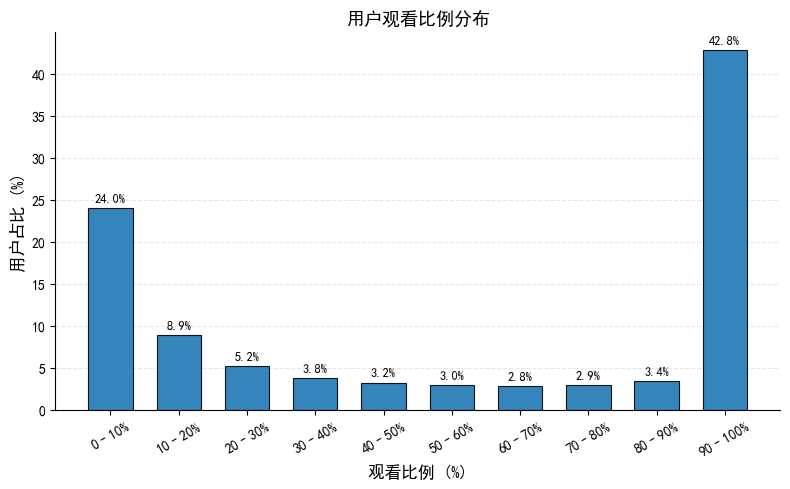

In [11]:
# ============================================================
# 观看比例分布
# ============================================================

ratio = data['view_ratio'].values

# 划分 10 个观看比例区间
bins = np.linspace(0, 1, 11)

counts, _ = np.histogram(
    ratio,
    bins=bins
)

percentage = (
    counts / len(ratio) * 100
)

labels = [
    '0–10%',
    '10–20%',
    '20–30%',
    '30–40%',
    '40–50%',
    '50–60%',
    '60–70%',
    '70–80%',
    '80–90%',
    '90–100%'
]


# ============================================================
# 绘图
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

x = np.arange(
    len(labels)
)

bars = ax.bar(
    x,
    percentage,
    width=0.65,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)


# ============================================================
# 数值标签
# ============================================================

for bar, value in zip(
    bars,
    percentage
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 坐标轴
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    rotation=30,
    fontsize=10
)

ax.set_xlabel(
    '观看比例 (%)',
    fontsize=12
)

ax.set_ylabel(
    '用户占比 (%)',
    fontsize=12
)

ax.set_title(
    '用户观看比例分布',
    fontsize=13
)


# ============================================================
# 网格
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 保存
# ============================================================

plt.tight_layout()

plt.savefig(
    'user_viewing_ratio.svg',
    bbox_inches='tight'
)
plt.show()

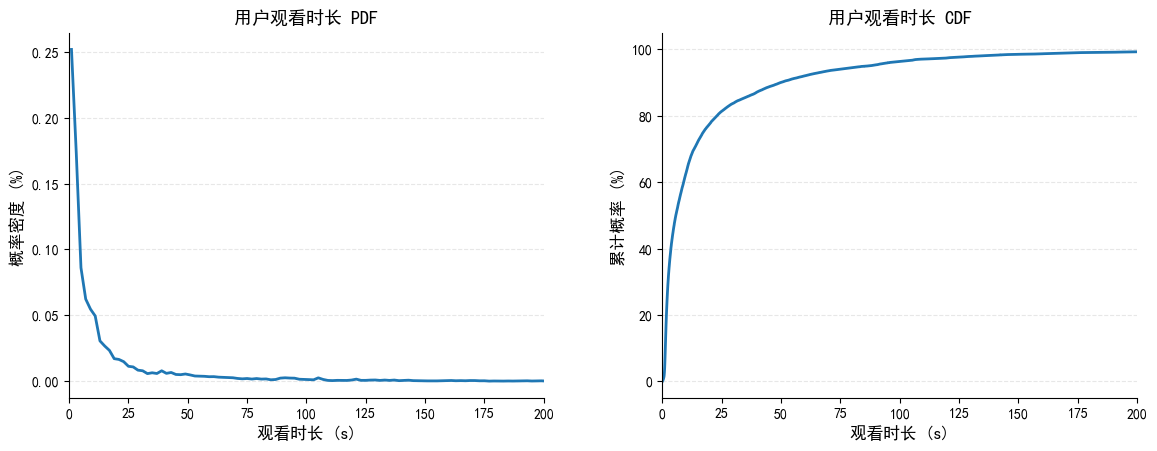

In [30]:
# # 存储到文件中
# file_store_play_time_s = './play_time_in_s'
# with open(file_store_play_time_s, 'w') as f:
#     for play_time_s in play_time_s_for_pdf_cdf:
#         f.write(str(play_time_s) + '\n')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取 playback.txt
# =========================
file_path = './play_time_in_s'

play_time_s_for_pdf_cdf = pd.read_csv(
    file_path,
    header=None,
)
duration = pd.Series(play_time_s_for_pdf_cdf[0])
# ============================================================
# PDF
# ============================================================

# 以 2s 为一个区间
time_interval = 2

bins = np.arange(
    0,
    duration.max() + time_interval,
    time_interval
)

counts, edges = np.histogram(
    duration,
    bins=bins
)

# 概率
pdf = counts / len(duration)

# 使用区间中点作为 X
x_pdf = (
    edges[:-1] + edges[1:]
) / 2


# ============================================================
# CDF
# ============================================================

duration_sorted = np.sort(duration)

cdf = (
    np.arange(1, len(duration_sorted) + 1)
    / len(duration_sorted)
)


# ============================================================
# 绘图
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ============================================================
# 左图：PDF
# ============================================================
axes[0].plot(
    x_pdf,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)
axes[0].set_xlim(0, 200)

axes[0].set_ylabel(
    '概率密度 (%)',
    fontsize=12
)

axes[0].set_title(
    '用户观看时长 PDF',
    fontsize=13
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ============================================================
# 右图：CDF
# ============================================================

axes[1].plot(
    duration_sorted,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)

axes[1].set_ylabel(
    '累计概率 (%)',
    fontsize=12
)

axes[1].set_title(
    '用户观看时长 CDF',
    fontsize=13
)

axes[1].set_xlim(
    0,
    200
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ============================================================
# Tick
# ============================================================

for ax in axes:

    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'user_viewing_duration_pdf_cdf.svg',
    bbox_inches='tight'
)

plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np


# =========================
# 1. 读取 playback.txt
# =========================
file_path = './play_percentage'

play_percentage_for_pdf_cdf = pd.read_csv(
    file_path,
    header=None,
)
play_percentage_for_pdf_cdf = pd.Series(play_percentage_for_pdf_cdf[0])

In [41]:
print(play_percentage_for_pdf_cdf.index)
print(play_percentage_for_pdf_cdf.sum())

RangeIndex(start=0, stop=10, step=1)
43687


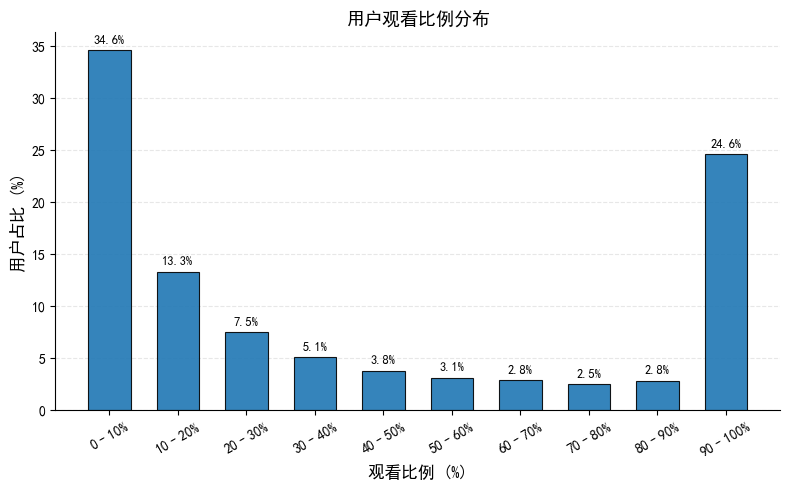

In [11]:
# =========================
# 数据
# =========================

x = np.arange(0, 100, 10)

pdf = (
    play_percentage_for_pdf_cdf.values
    / play_percentage_for_pdf_cdf.sum()
)

pdf = np.asarray(pdf)

# 转换为百分比
pdf_percentage = pdf * 100

labels = [
    '0–10%',
    '10–20%',
    '20–30%',
    '30–40%',
    '40–50%',
    '50–60%',
    '60–70%',
    '70–80%',
    '80–90%',
    '90–100%'
]

# =========================
# 创建图
# =========================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


# =========================
# 绘制柱状图
# =========================

bars = ax.bar(
    x,
    pdf_percentage,
    width=6.2,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)


# =========================
# 柱顶添加数值
# =========================

for bar, value in zip(
    bars,
    pdf_percentage
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )


# =========================
# 坐标轴标签
# =========================
ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    rotation=30,
    fontsize=10
)

ax.set_xlabel(
    '观看比例 (%)',
    fontsize=12
)

ax.set_ylabel(
    '用户占比 (%)',
    fontsize=12
)

ax.set_title(
    '用户观看比例分布',
    fontsize=13
)
# =========================
# 网格线
# =========================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)


# =========================
# 坐标轴边框
# =========================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================
# 布局
# =========================

plt.tight_layout()


# =========================
# 保存
# =========================

plt.savefig(
    'playback_percentage_distribution.svg',
    bbox_inches='tight'
)

plt.show()

       client_os  avg_view_duration  avg_view_ratio  sample_count
0  ANDROID_PHONE          24.765274        0.571098       2626925
2         IPHONE          24.740654        0.600898        255504
1           IPAD          30.923571        0.633489         23365


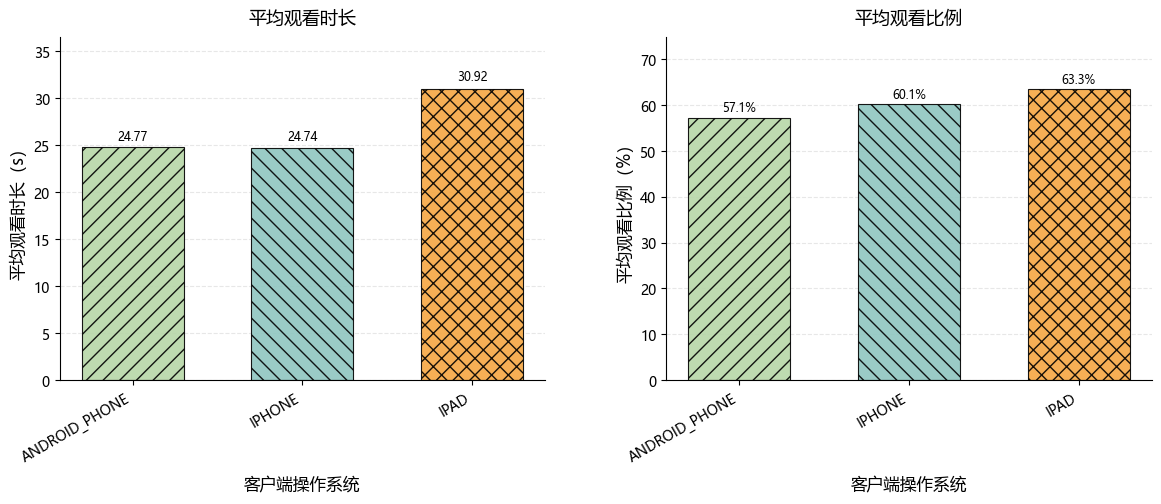

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取 playback.txt
# =========================
file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# 根据当前数据格式：
# 第4列：video_duration（ms）
# 第5列：playback_duration（ms）
# 第3列：client_os

df['video_duration'] = pd.to_numeric(df.iloc[:, 3], errors='coerce')
df['playback_duration'] = pd.to_numeric(df.iloc[:, 4], errors='coerce')
df['client_os'] = df.iloc[:, 2].astype(str)

# =========================
# 2. 数据清洗
# =========================
data = df[
    (df['video_duration'] > 0) &
    (df['playback_duration'] > 0)
].copy()

data['playback_duration'] = np.minimum(
    data['playback_duration'],
    data['video_duration']
)

# 转换为秒
data['view_duration'] = data['playback_duration'] / 1000

# 观看比例
data['view_ratio'] = (
    data['playback_duration'] /
    data['video_duration']
)

# =========================
# 3. 按 OS 分组统计
# =========================
os_stats = data.groupby('client_os').agg(
    avg_view_duration=('view_duration', 'mean'),
    avg_view_ratio=('view_ratio', 'mean'),
    sample_count=('view_duration', 'count')
).reset_index()

# 如果 OS 类别很多，可以按照样本量排序
os_stats = os_stats.sort_values(
    'sample_count',
    ascending=False
)

os_stats = os_stats[os_stats['sample_count'] > 100]
print(os_stats)

# =========================
# 4. 绘图
# =========================

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei'
]
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 绘图参数
# ============================================================

x = np.arange(len(os_stats))

bar_width = 0.60

colors = [
    '#B7D7A8',
    '#8FC6C0',
    '#F5A742',
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]
hatches = ['//', '\\\\', 'xx', '..', '++']


# ============================================================
# 创建两个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)


# ============================================================
# 子图 1：平均观看时长
# ============================================================

bars1 = axes[0].bar(
    x,
    os_stats['avg_view_duration'],
    width=bar_width,
    color=colors[:3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[:3],
    alpha=0.9
)


# 数值标签
for bar, value in zip(
    bars1,
    os_stats['avg_view_duration']
):

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + value * 0.02,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=8.5
    )


axes[0].set_xticks(x)

axes[0].set_xticklabels(
    os_stats['client_os'],
    rotation=30,
    ha='right',
    fontsize=9
)

axes[0].set_xlabel(
    '客户端操作系统',
    fontsize=12,
    labelpad=8
)

axes[0].set_ylabel(
    '平均观看时长（s）',
    fontsize=12
)

axes[0].set_title(
    '平均观看时长',
    fontsize=13,
    pad=10
)


# 根据数据自动设置 y 轴
max_duration = os_stats['avg_view_duration'].max()

axes[0].set_ylim(
    0,
    max_duration * 1.18
)


# 网格
axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)


# ============================================================
# 子图 2：平均观看比例
# ============================================================

view_ratio_percent = (
    os_stats['avg_view_ratio'] * 100
)

bars2 = axes[1].bar(
    x,
    view_ratio_percent,
    width=bar_width,
    color=colors[:3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[:3],
    alpha=0.9
)


# 数值标签
for bar, value in zip(
    bars2,
    view_ratio_percent
):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8.5
    )


axes[1].set_xticks(x)

axes[1].set_xticklabels(
    os_stats['client_os'],
    rotation=30,
    ha='right',
    fontsize=9
)

axes[1].set_xlabel(
    '客户端操作系统',
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel(
    '平均观看比例（%）',
    fontsize=12
)

axes[1].set_title(
    '平均观看比例',
    fontsize=13,
    pad=10
)


# 根据数据自动设置 y 轴
max_ratio = view_ratio_percent.max()

axes[1].set_ylim(
    0,
    max_ratio * 1.18
)


# 网格
axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)


# ============================================================
# 统一美化
# ============================================================

for ax in axes:

    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.22,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'user_behavior_by_os.svg',
    bbox_inches='tight'
)

plt.show()

   client_os  avg_view_duration  avg_view_ratio  sample_count
3       WIFI          24.854903        0.571871       2591139
1  MOBILE_4G          24.523804        0.594185        290971
0  MOBILE_3G          23.732371        0.585846         23648


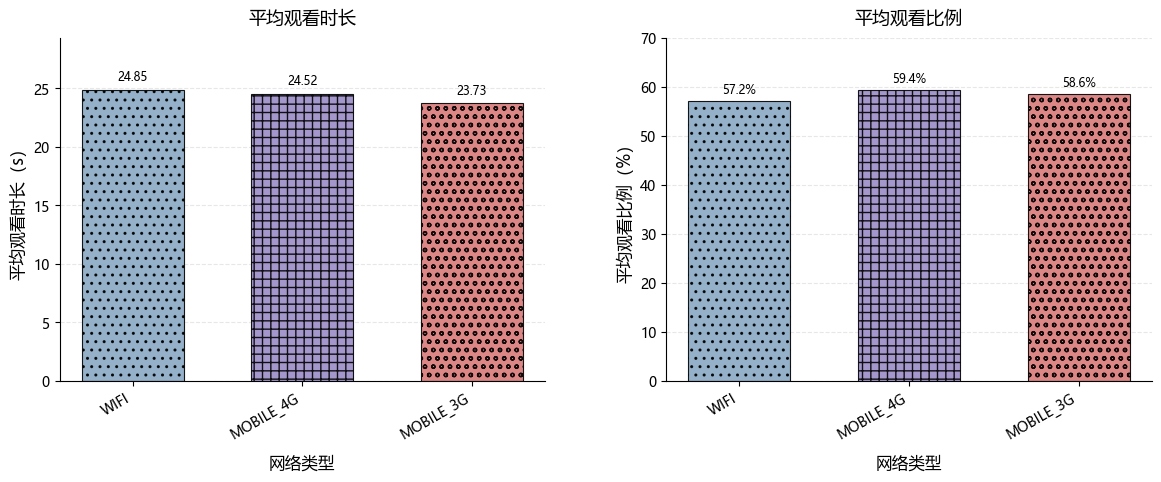

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取 playback.txt
# =========================
file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# 根据当前数据格式：
# 第4列：video_duration（ms）
# 第5列：playback_duration（ms）
# 第3列：client_os

df['video_duration'] = pd.to_numeric(df.iloc[:, 3], errors='coerce')
df['playback_duration'] = pd.to_numeric(df.iloc[:, 4], errors='coerce')
df['client_os'] = df.iloc[:, 12].astype(str)

# =========================
# 2. 数据清洗
# =========================
data = df[
    (df['video_duration'] > 0) &
    (df['playback_duration'] > 0)
].copy()

data['playback_duration'] = np.minimum(
    data['playback_duration'],
    data['video_duration']
)

# 转换为秒
data['view_duration'] = data['playback_duration'] / 1000

# 观看比例
data['view_ratio'] = (
    data['playback_duration'] /
    data['video_duration']
)

# =========================
# 3. 按 OS 分组统计
# =========================
os_stats = data.groupby('client_os').agg(
    avg_view_duration=('view_duration', 'mean'),
    avg_view_ratio=('view_ratio', 'mean'),
    sample_count=('view_duration', 'count')
).reset_index()

# 如果 OS 类别很多，可以按照样本量排序
os_stats = os_stats.sort_values(
    'sample_count',
    ascending=False
)

os_stats = os_stats[os_stats['sample_count'] > 100]
print(os_stats)

# =========================
# 4. 绘图
# =========================

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei'
]
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 绘图参数
# ============================================================

x = np.arange(len(os_stats))

bar_width = 0.60

colors = [
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]
hatches = ['..', '++', 'oo']


# ============================================================
# 创建两个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)


# ============================================================
# 子图 1：平均观看时长
# ============================================================

bars1 = axes[0].bar(
    x,
    os_stats['avg_view_duration'],
    width=bar_width,
    color=colors[:3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[:3],
    alpha=0.9
)


# 数值标签
for bar, value in zip(
    bars1,
    os_stats['avg_view_duration']
):

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + value * 0.02,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=8.5
    )


axes[0].set_xticks(x)

axes[0].set_xticklabels(
    os_stats['client_os'],
    rotation=30,
    ha='right',
    fontsize=9
)

axes[0].set_xlabel(
    '网络类型',
    fontsize=12,
    labelpad=8
)

axes[0].set_ylabel(
    '平均观看时长（s）',
    fontsize=12
)

axes[0].set_title(
    '平均观看时长',
    fontsize=13,
    pad=10
)


# 根据数据自动设置 y 轴
max_duration = os_stats['avg_view_duration'].max()

axes[0].set_ylim(
    0,
    max_duration * 1.18
)


# 网格
axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)


# ============================================================
# 子图 2：平均观看比例
# ============================================================

view_ratio_percent = (
    os_stats['avg_view_ratio'] * 100
)

bars2 = axes[1].bar(
    x,
    view_ratio_percent,
    width=bar_width,
    color=colors[:3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[:3],
    alpha=0.9
)


# 数值标签
for bar, value in zip(
    bars2,
    view_ratio_percent
):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8.5
    )


axes[1].set_xticks(x)

axes[1].set_xticklabels(
    os_stats['client_os'],
    rotation=30,
    ha='right',
    fontsize=9
)

axes[1].set_xlabel(
    '网络类型',
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel(
    '平均观看比例（%）',
    fontsize=12
)

axes[1].set_title(
    '平均观看比例',
    fontsize=13,
    pad=10
)


# 根据数据自动设置 y 轴
max_ratio = view_ratio_percent.max()

axes[1].set_ylim(
    0,
    max_ratio * 1.18
)


# 网格
axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)


# ============================================================
# 统一美化
# ============================================================

for ax in axes:

    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.22,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'user_behavior_by_network_type.svg',
    bbox_inches='tight'
)

plt.show()

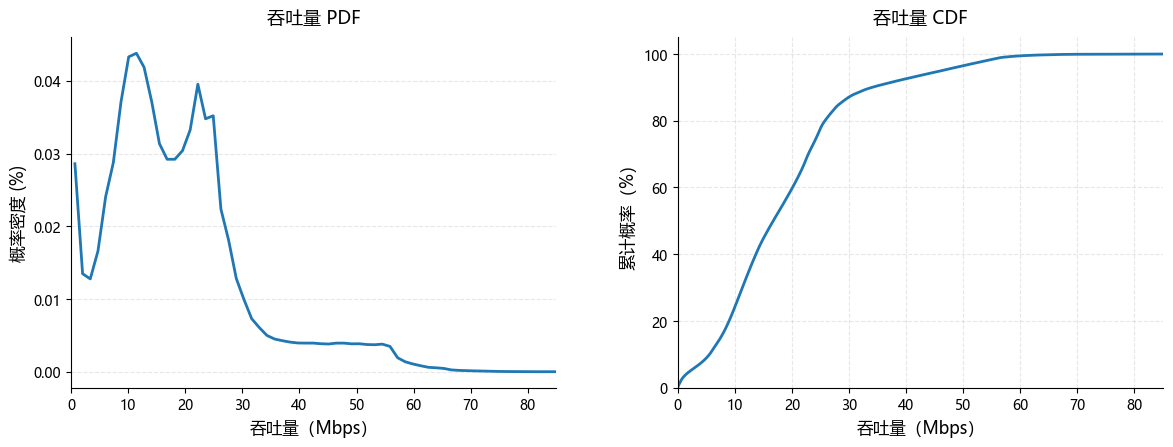

网络吞吐量统计
样本数量: 1715.04
平均吞吐量: 18.75 Mbps
中位数: 16.73 Mbps
P25: 10.19 Mbps
P75: 24.30 Mbps
最小值: 0.01 Mbps
最大值: 134.59 Mbps
标准差: 12.34 Mbps


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取网络数据
# =========================
network_dataset = pd.read_csv(
    'data/network_traces/NewFile-HighDensity-4G.txt',
    header=None
)

# 转换为一维数组，并去除缺失值
network_data = network_dataset.values.flatten()
network_data = network_data[~pd.isna(network_data)]
network_data = network_data[network_data != 0]
network_data = network_data.astype(float) / 1000. * 8
# =========================
# 2. PDF
# =========================
# 使用直方图统计概率密度
pdf, bins = np.histogram(
    network_data,
    bins=100,
    density=True
)

bin_centers = (bins[:-1] + bins[1:]) / 2

# =========================
# 3. CDF
# =========================
sorted_data = np.sort(network_data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# =========================
# 4. 绘图
# =========================

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei'
]
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 创建两个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8)
)


# ============================================================
# 子图 1：PDF
# ============================================================

axes[0].plot(
    bin_centers,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '吞吐量（Mbps）',
    fontsize=12,
)

axes[0].set_xlim(0, 85)

axes[0].set_ylabel(
    '概率密度 (%)',
    fontsize=12
)

axes[0].set_title(
    '吞吐量 PDF',
    fontsize=13,
    pad=10
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)


# ============================================================
# 子图 2：CDF
# ============================================================

axes[1].plot(
    sorted_data,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel(
    '吞吐量（Mbps）',
    fontsize=12,
)
axes[1].set_xlim(0, 85)

axes[1].set_ylabel(
    '累计概率（%）',
    fontsize=12
)

axes[1].set_title(
    '吞吐量 CDF',
    fontsize=13,
    pad=10
)

axes[1].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].set_ylim(
    0,
    105
)


# ============================================================
# 统一美化
# ============================================================

for ax in axes:

    # 去除顶部、右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'network_throughput_distribution.svg',
    bbox_inches='tight'
)

plt.show()


# =========================
# 5. 输出基本统计量
# =========================

print('=' * 50)
print('网络吞吐量统计')
print('=' * 50)

print(f'样本数量: {len(network_data) / 3600:.2f}')

print(
    f'平均吞吐量: '
    f'{np.mean(network_data):.2f} Mbps'
)

print(
    f'中位数: '
    f'{np.median(network_data):.2f} Mbps'
)

print(
    f'P25: '
    f'{np.percentile(network_data, 25):.2f} Mbps'
)

print(
    f'P75: '
    f'{np.percentile(network_data, 75):.2f} Mbps'
)

print(
    f'最小值: '
    f'{np.min(network_data):.2f} Mbps'
)

print(
    f'最大值: '
    f'{np.max(network_data):.2f} Mbps'
)

print(
    f'标准差: '
    f'{np.std(network_data):.2f} Mbps'
)

原始数据维度： (12047324, 16)

吞吐量基本统计（未去除异常值）：
count    1.192903e+07
mean     3.326716e+01
std      1.555224e+02
min      9.580838e-05
25%      1.077794e+01
50%      2.118335e+01
75%      3.247970e+01
max      8.388608e+03
Name: throughput_mbps, dtype: float64

总体网络吞吐量统计
样本数量： 11,809,742
平均值：   22.36 Mbps
中位数：   20.97 Mbps
P25：      10.67 Mbps
P75：      32.14 Mbps
最大值：   84.09 Mbps
最小值：   0.00 Mbps


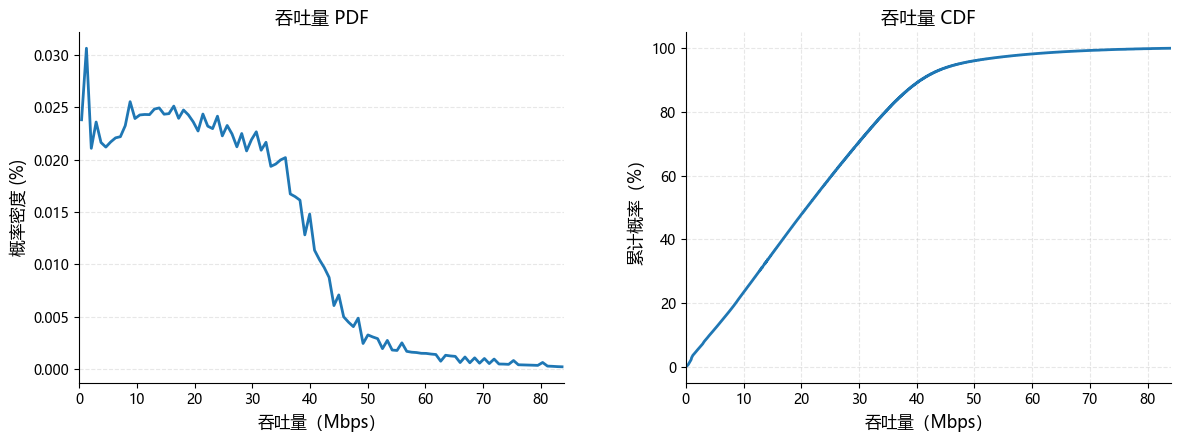


Network Type 样本数量
network_type
WIFI         10635855
MOBILE_4G     1086457
MOBILE_3G       87287
MOBILE_5G         143
Name: count, dtype: int64

Client OS 样本数量
client_os
ANDROID_PHONE    10749688
IPHONE             955904
IPAD               104141
UNKNOWN2                9
Name: count, dtype: int64

ISP 样本数量
isp
f6f77a498c2b2c7e04ead59fbeec5128    3970062
68d982a1cc0358bd08c0d6c7db88c238    3396511
8604270694837d14d85ca6db182c7375    2859655
d0d357dbee6fda491c1f8d8858c459c4    1120422
e25628982fa2a335197fedb0cecc1654     268229
983a43c1d1f3d634609bb858faf66052     117638
d8d135f8d7975d760679dd0681193231      56399
1a16530bfabf83d0177947f3cbaec652      20135
2b2255b92b7f816a68d590042b92072f        347
696b031073e74bf2cb98e5ef201d4aa3        280
3ce81858dbce80c46ab03c253096bb97         64
Name: count, dtype: int64


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 读取 download.txt
# ============================================================

file_path = 'data/download.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

print('原始数据维度：', df.shape)


# ============================================================
# 2. 字段位置
# ============================================================

# 根据你提供的 download.txt 示例
CLIENT_DOWNLOAD_SIZE_COL = 7     # client_download_size
NETWORK_COST_COL = 8             # network_cost
NETWORK_TYPE_COL = 11            # network_type

# ------------------------------------------------------------
# 下面两个需要根据你的完整字段定义确认
# ------------------------------------------------------------

CLIENT_OS_COL = 2                 # 示例中 ANDROID_PHONE 所在列
ISP_COL = 14                       # !!! 请根据实际字段确认


# ============================================================
# 3. 提取数据
# ============================================================

data = pd.DataFrame({
    'client_download_size': pd.to_numeric(
        df.iloc[:, CLIENT_DOWNLOAD_SIZE_COL],
        errors='coerce'
    ),

    'network_cost': pd.to_numeric(
        df.iloc[:, NETWORK_COST_COL],
        errors='coerce'
    ),

    'network_type': df.iloc[:, NETWORK_TYPE_COL].astype(str),

    'client_os': df.iloc[:, CLIENT_OS_COL].astype(str),

    'isp': df.iloc[:, ISP_COL].astype(str)
})


# ============================================================
# 4. 数据清洗
# ============================================================

# 下载大小和网络耗时必须有效
data = data.dropna(
    subset=[
        'client_download_size',
        'network_cost'
    ]
)

# 下载大小 > 0
# 网络耗时 > 0
data = data[
    (data['client_download_size'] > 0) &
    (data['network_cost'] > 0)
].copy()


# ============================================================
# 5. 计算实际下载吞吐量
# ============================================================

# client_download_size：Byte
# network_cost：ms
#
# Mbps =
# Byte × 8 / (ms / 1000) / 1,000,000
#
# 即：
# Byte × 8 × 1000 / ms / 1e6

data['throughput_mbps'] = (
    data['client_download_size'] * 8
    / data['network_cost']
    * 1000
    / 1e6
)


# ============================================================
# 6. 去除明显异常值
# ============================================================

# 这里暂时不直接删除异常值。
# 先查看原始分布。

print('\n吞吐量基本统计（未去除异常值）：')
print(
    data['throughput_mbps'].describe(
        percentiles=[0.25, 0.50, 0.75]
    )
)
x_max = data['throughput_mbps'].quantile(0.99)
data = data[data['throughput_mbps'] < x_max]


# ============================================================
# 7. 总体吞吐量统计
# ============================================================

throughput = data['throughput_mbps']

print('\n' + '=' * 60)
print('总体网络吞吐量统计')
print('=' * 60)

print(f'样本数量： {len(throughput):,}')
print(f'平均值：   {throughput.mean():.2f} Mbps')
print(f'中位数：   {throughput.median():.2f} Mbps')
print(f'P25：      {throughput.quantile(0.25):.2f} Mbps')
print(f'P75：      {throughput.quantile(0.75):.2f} Mbps')
print(f'最大值：   {throughput.max():.2f} Mbps')
print(f'最小值：   {throughput.min():.2f} Mbps')


# ============================================================
# 8. 总体吞吐量 CDF
# ============================================================

sorted_throughput = np.sort(
    throughput.values
)

cdf = (
    np.arange(1, len(sorted_throughput) + 1)
    / len(sorted_throughput)
)


# ============================================================
# 9. 绘图参数
# ============================================================

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei'
]

plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 10. 绘制总体吞吐量 PDF + CDF
# ============================================================
# ============================================================
# PDF
# ============================================================

# 只使用 x_max 范围内的数据进行 PDF 统计
throughput_pdf = throughput.values

pdf, bins = np.histogram(
    throughput_pdf,
    bins=100,
    density=True
)

bin_centers = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# CDF
# ============================================================

sorted_throughput = np.sort(
    throughput_pdf
)

cdf = (
    np.arange(
        1,
        len(sorted_throughput) + 1
    )
    / len(sorted_throughput)
)


# ============================================================
# 创建双子图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8)
)


# ============================================================
# 左图：PDF
# ============================================================

axes[0].plot(
    bin_centers,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '吞吐量（Mbps）',
    fontsize=12
)

axes[0].set_ylabel(
    '概率密度 (%)',
    fontsize=12
)

axes[0].set_title(
    '吞吐量 PDF',
    fontsize=13
)

axes[0].set_xlim(
    0,
    x_max
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)


# ============================================================
# 右图：CDF
# ============================================================

axes[1].plot(
    sorted_throughput,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel(
    '吞吐量（Mbps）',
    fontsize=12
)

axes[1].set_ylabel(
    '累计概率（%）',
    fontsize=12
)

axes[1].set_title(
    '吞吐量 CDF',
    fontsize=13
)

axes[1].set_xlim(
    0,
    x_max
)

axes[1].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)


# ============================================================
# 统一美化
# ============================================================

for ax in axes:

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'throughput_pdf_cdf.svg',
    bbox_inches='tight'
)

plt.show()


# ============================================================
# 11. 输出不同网络属性的样本数量
# ============================================================

print('\n' + '=' * 60)
print('Network Type 样本数量')
print('=' * 60)

print(
    data['network_type']
    .value_counts()
)

print('\n' + '=' * 60)
print('Client OS 样本数量')
print('=' * 60)

print(
    data['client_os']
    .value_counts()
)

print('\n' + '=' * 60)
print('ISP 样本数量')
print('=' * 60)

print(
    data['isp']
    .value_counts()
)

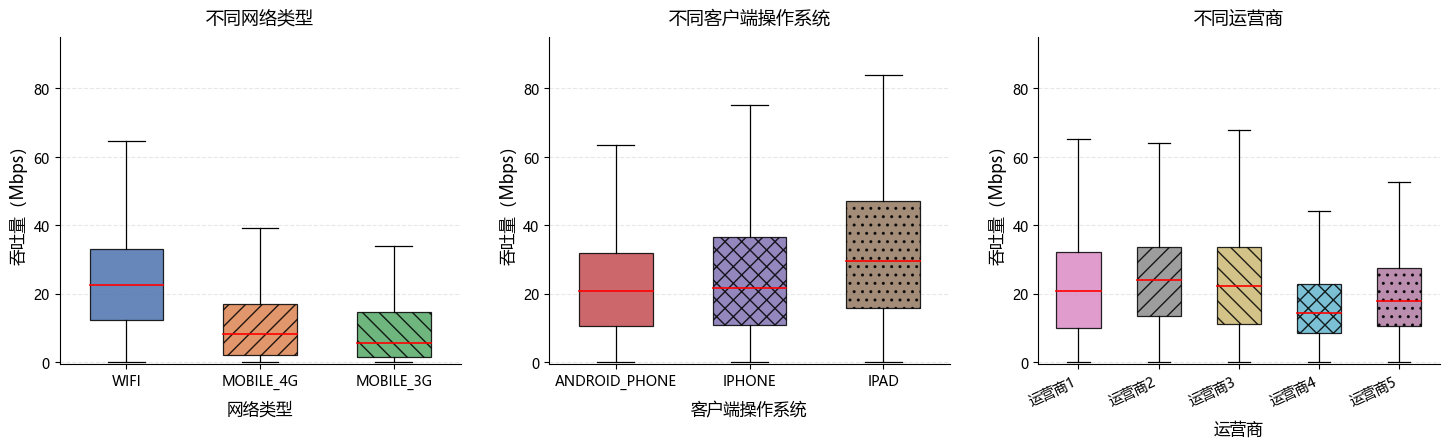

In [49]:
#===============================================
# 12. 三类网络属性箱线图绘制
# ============================================================

def prepare_boxplot_data(
    data,
    group_col,
    value_col,
    top_n=None
):
    """
    根据样本数量选择类别，并按照样本数量从高到低排列
    """

    plot_data = data.copy()

    # --------------------------------------------------------
    # 选择样本量最多的类别
    # --------------------------------------------------------

    if top_n is not None:

        top_categories = (
            plot_data[group_col]
            .value_counts()
            .head(top_n)
            .index
        )

        plot_data = plot_data[
            plot_data[group_col].isin(top_categories)
        ]

    # 按样本数量排序
    categories = (
        plot_data[group_col]
        .value_counts()
        .index
        .tolist()
    )

    # --------------------------------------------------------
    # 准备箱线图数据
    # --------------------------------------------------------

    box_data = []

    for category in categories:

        values = plot_data.loc[
            plot_data[group_col] == category,
            value_col
        ].dropna().values

        box_data.append(values)

    return categories, box_data


# ============================================================
# 13. 准备三个分组的数据
# ============================================================

# Network Type
network_categories, network_box_data = prepare_boxplot_data(
    data=data,
    group_col='network_type',
    value_col='throughput_mbps',
    top_n=3
)


# Client OS
os_categories, os_box_data = prepare_boxplot_data(
    data=data,
    group_col='client_os',
    value_col='throughput_mbps',
    top_n=3
)


# ISP
isp_categories, isp_box_data = prepare_boxplot_data(
    data=data,
    group_col='isp',
    value_col='throughput_mbps',
    top_n=5
)


# ============================================================
# 14. 绘图参数
# ============================================================

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei'
]

plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 15. 创建三个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8)
)


# ============================================================
# 16. 统一箱线图样式
# ============================================================

def style_boxplot(
    ax,
    box_data,
    categories,
    title,
    xlabel,
    show_ylabel=True,
    colors=None,
    hatches=None,
):

    # --------------------------------------------------------
    # 绘制箱线图
    # --------------------------------------------------------

    bp = ax.boxplot(
        box_data,
        labels=categories,
        showfliers=False,
        widths=0.55,
        patch_artist=True,
    )

    # --------------------------------------------------------
    # 设置箱体
    # --------------------------------------------------------

    for i, box in enumerate(bp['boxes']):

        box.set(
            facecolor=colors[i % len(colors)],
            edgecolor='black',
            linewidth=0.9,
            hatch=hatches[i % len(hatches)],
            alpha=0.85
        )

    # --------------------------------------------------------
    # 中位数
    # --------------------------------------------------------

    for median in bp['medians']:

        median.set(
            color='red',
            linewidth=1.2
        )

    # --------------------------------------------------------
    # 须
    # --------------------------------------------------------

    for whisker in bp['whiskers']:

        whisker.set(
            color='black',
            linewidth=0.9
        )

    # --------------------------------------------------------
    # 端帽
    # --------------------------------------------------------

    for cap in bp['caps']:

        cap.set(
            color='black',
            linewidth=0.9
        )

    # --------------------------------------------------------
    # 坐标轴
    # --------------------------------------------------------

    if show_ylabel:

        ax.set_ylabel(
            '吞吐量（Mbps）',
            fontsize=12
        )

    ax.set_xlabel(
        xlabel,
        fontsize=12,
        labelpad=8
    )

    ax.set_title(
        title,
        fontsize=13,
        pad=10
    )

    # --------------------------------------------------------
    # X轴标签
    # --------------------------------------------------------

    ax.tick_params(
        axis='both',
        labelsize=10
    )

    # 类别较多时旋转标签
    if len(categories) >= 4:

        ax.set_xticklabels(
            categories,
            rotation=25,
            ha='right'
        )

    # --------------------------------------------------------
    # 网格
    # --------------------------------------------------------

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.set_axisbelow(True)

    # --------------------------------------------------------
    # 边框
    # --------------------------------------------------------

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ============================================================
# 17. 子图 1：Network Type
# ============================================================

# --------------------------------------------------------
# 箱体颜色
# --------------------------------------------------------

colors_subplots = {
    'subplot1': ['#4C72B0', '#DD8452', '#55A868'],              # 3类
    'subplot2': ['#C44E52', '#8172B3', '#937860'],              # 3类
    'subplot3': ['#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD', '#B07AA1'],  # 5类
}

# --------------------------------------------------------
# Hatch
# --------------------------------------------------------

hatches_subplots = {
    'subplot1': ['', '//', '\\\\'],                              # 实心、斜线、反斜线
    'subplot2': ['', 'xx', '..'],                                # 实心、交叉、点
    'subplot3': ['', '//', '\\\\', 'xx', '..'],                  # 5种
}
style_boxplot(
    ax=axes[0],

    box_data=network_box_data,
    categories=network_categories,

    title='不同网络类型',
    xlabel='网络类型',

    show_ylabel=True,
    
    colors=colors_subplots['subplot1'],
    hatches=hatches_subplots['subplot1'],
)


# ============================================================
# 18. 子图 2：Client OS
# ============================================================

style_boxplot(
    ax=axes[1],

    box_data=os_box_data,
    categories=os_categories,

    title='不同客户端操作系统',
    xlabel='客户端操作系统',

    show_ylabel=True,
    
    colors=colors_subplots['subplot2'],
    hatches=hatches_subplots['subplot2'],
)


# ============================================================
# 19. 子图 3：ISP
# ============================================================

isp_categories_for_boxplot = []
for i in range(len(isp_categories)):
    isp_categories_for_boxplot.append('运营商' + str(i + 1))
style_boxplot(
    ax=axes[2],

    box_data=isp_box_data,
    categories=isp_categories_for_boxplot,

    title='不同运营商',
    xlabel='运营商',

    show_ylabel=True,
    
    colors=colors_subplots['subplot3'],
    hatches=hatches_subplots['subplot3'],
)


# ============================================================
# 20. 三个子图统一 Y 轴
# ============================================================

# 使用所有数据的 99% 分位数限制显示范围，
# 避免极端吞吐量导致主体分布被压缩。

y_max = data['throughput_mbps'].quantile(0.99)

for ax in axes:

    ax.set_ylim(
        -0.5,
        95
    )


# ============================================================
# 21. 调整刻度
# ============================================================

for ax in axes:

    ax.tick_params(
        axis='y',
        labelsize=10
    )

    ax.tick_params(
        axis='x',
        labelsize=10
    )


# ============================================================
# 22. 整体布局
# ============================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.20,
    top=0.88,
    wspace=0.22
)


# ============================================================
# 23. 保存
# ============================================================

plt.savefig(
    'throughput_by_network_attributes.svg',
    bbox_inches='tight'
)


# ============================================================
# 24. 显示
# ============================================================

plt.show()

数据统计

有效卡顿数据： 2973802

卡顿次数统计：
count    2.973802e+06
mean     2.552961e-02
std      2.243393e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.200000e+01
Name: block_count, dtype: float64

卡顿总时长统计（秒）：
count    2.973802e+06
mean     9.105475e-02
std      1.377028e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.612300e+02
Name: block_duration_s, dtype: float64

启动时间统计（秒）：
count    2.904080e+06
mean     5.645944e-01
std      2.765864e+01
min      0.000000e+00
25%      2.360000e-01
50%      3.380000e-01
75%      4.970000e-01
max      4.409748e+04
Name: 16, dtype: float64


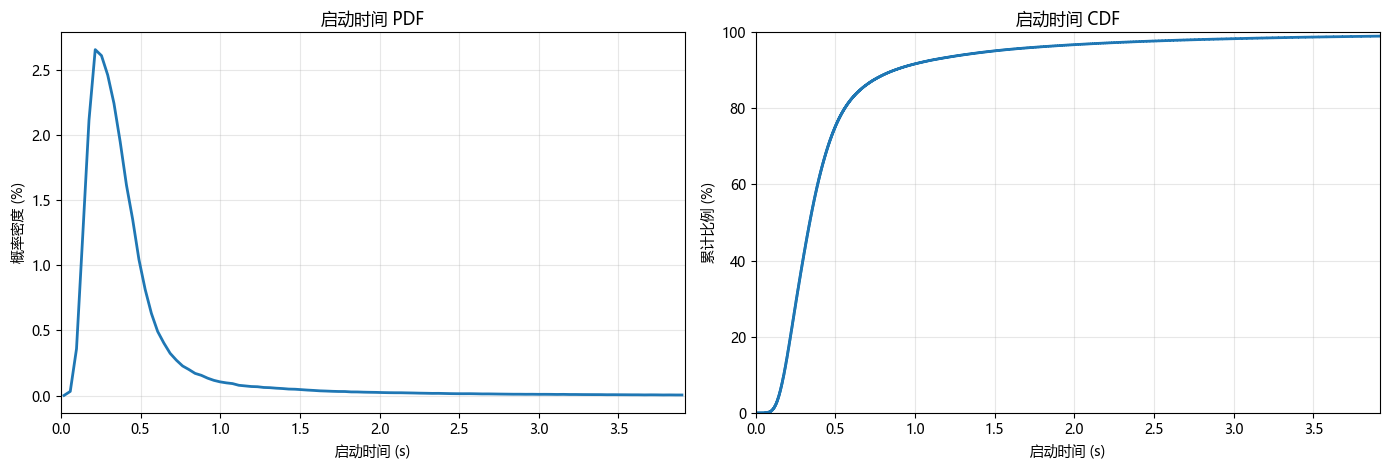

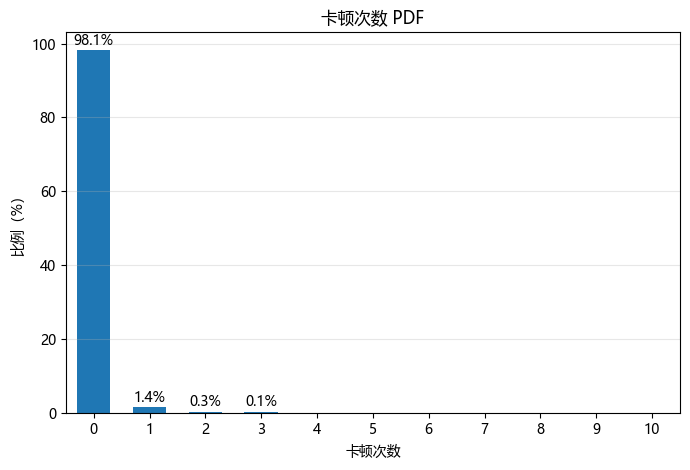

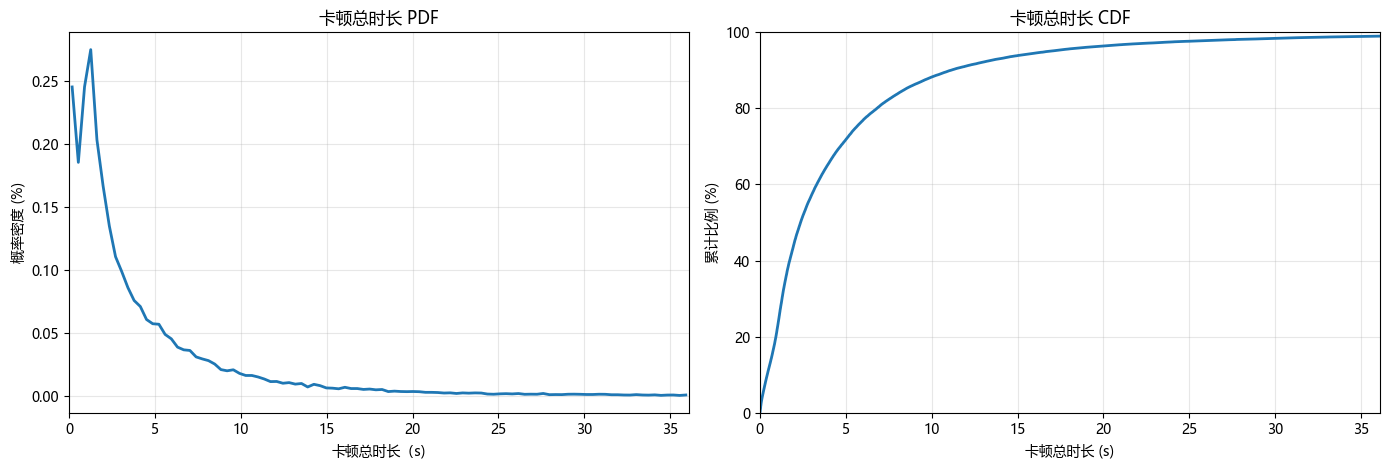

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 读取 playback.txt
# ============================================================
file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# ============================================================
# 2. 提取数据
# ============================================================

# ---------- 卡顿 ----------
data = pd.DataFrame({
    'block_count': pd.to_numeric(df.iloc[:, 8], errors='coerce'),
    'block_duration': pd.to_numeric(df.iloc[:, 9], errors='coerce')
})

data = data.dropna()

data = data[
    (data['block_count'] >= 0) &
    (data['block_duration'] >= 0)
].copy()

# ms -> s
data['block_duration_s'] = data['block_duration'] / 1000


# ---------- 启动时间 ----------
startup_time = pd.to_numeric(
    df.iloc[:, 16],
    errors='coerce'
)

startup_time = startup_time.dropna()
startup_time = startup_time[startup_time >= 0]

# ms -> s
startup_time_s = startup_time / 1000


# ============================================================
# 3. 基本统计
# ============================================================

print('=' * 60)
print('数据统计')
print('=' * 60)

print('\n有效卡顿数据：', len(data))

print('\n卡顿次数统计：')
print(data['block_count'].describe())

print('\n卡顿总时长统计（秒）：')
print(data['block_duration_s'].describe())

print('\n启动时间统计（秒）：')
print(startup_time_s.describe())


# ============================================================
# 4. 绘图参数
# ============================================================

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 5. 启动时间 PDF + CDF
# ============================================================

# 为了避免极端值影响图形展示，只展示 99% 分位数以内
startup_xmax = startup_time_s.quantile(0.99)

startup_plot = startup_time_s[
    startup_time_s <= startup_xmax
].values

# ---------- PDF ----------
pdf, bins = np.histogram(
    startup_plot,
    bins=100,
    density=True
)

bin_centers = (bins[:-1] + bins[1:]) / 2

# ---------- CDF ----------
startup_sorted = np.sort(startup_time_s.values)

cdf = (
    np.arange(1, len(startup_sorted) + 1)
    / len(startup_sorted)
)

# ---------- 绘图 ----------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 4.8)
)

# PDF
axes[0].plot(
    bin_centers,
    pdf,
    linewidth=2
)

axes[0].set_xlabel('启动时间 (s)')
axes[0].set_ylabel('概率密度 (%)')
axes[0].set_title('启动时间 PDF')
axes[0].set_xlim(0, startup_xmax)
axes[0].grid(alpha=0.3)

# CDF
axes[1].plot(
    startup_sorted,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel('启动时间 (s)')
axes[1].set_ylabel('累计比例 (%)')
axes[1].set_title('启动时间 CDF')
axes[1].set_xlim(0, startup_xmax)
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pdf_cdf_start_time.svg')
plt.show()


# ============================================================
# 6. 卡顿次数 PDF + CDF
# ============================================================

# 卡顿次数是离散变量
count_dist = (
    data['block_count']
    .value_counts(normalize=True)
    .sort_index()
)

# 只展示 0~10 次
count_plot = count_dist[
    count_dist.index <= 10
]

# ---------- CDF ----------
count_cdf = count_plot.cumsum()

# ---------- 绘图 ----------
fig, axes = plt.subplots(
    1, 1,
    figsize=(7, 4.8)
)

# PDF
bars = axes.bar(
    count_plot.index,
    count_plot.values * 100,
    width=0.6
)

# 在柱子顶部添加具体数值
for bar in bars:
    height = bar.get_height()
    if height < 0.1:
        break
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

axes.set_xlabel('卡顿次数')
axes.set_ylabel('比例（%）')
axes.set_title('卡顿次数 PDF')
axes.set_xticks(count_plot.index)
axes.set_xlim(-0.5, 10.5)
axes.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig('pdf_rebuff_count.svg')
plt.show()


# ============================================================
# 7. 卡顿总时长 PDF + CDF
# ============================================================

# 只考虑发生卡顿的播放过程
duration = data.loc[
    data['block_duration_s'] > 0,
    'block_duration_s'
]

# 为避免极端长卡顿影响显示
duration_xmax = duration.quantile(0.99)

duration_plot = duration[
    duration <= duration_xmax
].values

# ---------- PDF ----------
pdf, bins = np.histogram(
    duration_plot,
    bins=100,
    density=True
)

bin_centers = (bins[:-1] + bins[1:]) / 2

# ---------- CDF ----------
duration_sorted = np.sort(duration.values)

cdf = (
    np.arange(1, len(duration_sorted) + 1)
    / len(duration_sorted)
)

# ---------- 绘图 ----------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 4.8)
)

# PDF
axes[0].plot(
    bin_centers,
    pdf,
    linewidth=2
)

axes[0].set_xlabel('卡顿总时长（s)')
axes[0].set_ylabel('概率密度 (%)')
axes[0].set_title('卡顿总时长 PDF')
axes[0].set_xlim(0, duration_xmax)
axes[0].grid(alpha=0.3)

# CDF
axes[1].plot(
    duration_sorted,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel('卡顿总时长 (s)')
axes[1].set_ylabel('累计比例 (%)')
axes[1].set_title('卡顿总时长 CDF')
axes[1].set_xlim(0, duration_xmax)
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig('pdf_cdf_rebuff.svg')
plt.show()

网络类型样本数量
network_type
WIFI         2589788
MOBILE_4G     290638
MOBILE_3G      23613
Name: count, dtype: int64

网络类型比例
network_type
WIFI         0.891788
MOBILE_4G    0.100081
MOBILE_3G    0.008131
Name: proportion, dtype: float64

播放体验统计
              startup_mean  startup_median  rebuff_count_mean  \
network_type                                                    
MOBILE_3G         1.129100           0.555           0.108457   
MOBILE_4G         0.886441           0.433           0.078985   
WIFI              0.523319           0.329           0.019323   

              rebuff_count_median  rebuff_duration_mean  \
network_type                                              
MOBILE_3G                     0.0              0.418121   
MOBILE_4G                     0.0              0.266979   
WIFI                          0.0              0.070186   

              rebuff_duration_median  
network_type                          
MOBILE_3G                        0.0  
MOBILE_4G             

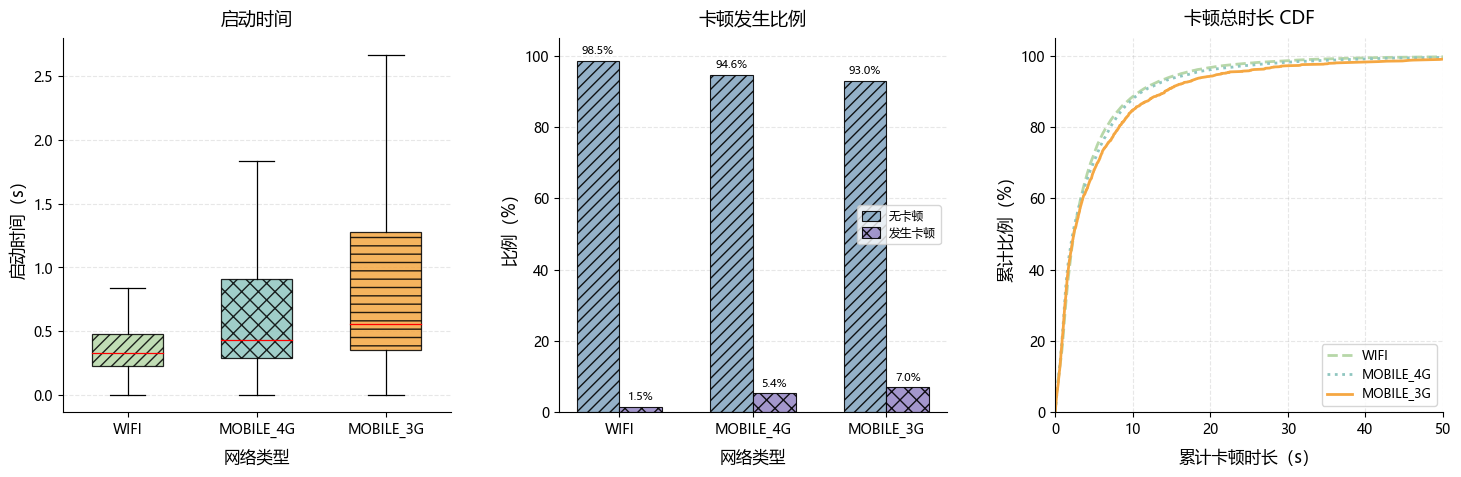

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 读取 playback.txt
# ============================================================

file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# ============================================================
# 2. 提取字段
# ============================================================

data = pd.DataFrame({
    'network_type': df.iloc[:, 12].astype(str),

    # 启动时间，单位 ms
    'startup_time': pd.to_numeric(
        df.iloc[:, 16],
        errors='coerce'
    ),

    # 卡顿次数
    'block_count': pd.to_numeric(
        df.iloc[:, 8],
        errors='coerce'
    ),

    # 卡顿总时长，单位 ms
    'block_duration': pd.to_numeric(
        df.iloc[:, 9],
        errors='coerce'
    )
})

# ============================================================
# 3. 数据清洗
# ============================================================

data = data[
    data['network_type'].isin(['WIFI', 'MOBILE_4G', 'MOBILE_3G'])
].copy()

data = data.dropna()

data = data[
    (data['startup_time'] >= 0) &
    (data['block_count'] >= 0) &
    (data['block_duration'] >= 0)
].copy()

# ms → s
data['startup_time_s'] = data['startup_time'] / 1000
data['block_duration_s'] = data['block_duration'] / 1000

# 网络类型名称
network_labels = ['WIFI', 'MOBILE_4G', 'MOBILE_3G']

# ============================================================
# 4. 输出基本统计结果
# ============================================================

print('=' * 60)
print('网络类型样本数量')
print('=' * 60)

print(data['network_type'].value_counts())

print('\n网络类型比例')
print(data['network_type'].value_counts(normalize=True))

print('\n' + '=' * 60)
print('播放体验统计')
print('=' * 60)

stats = data.groupby('network_type').agg(
    startup_mean=('startup_time_s', 'mean'),
    startup_median=('startup_time_s', 'median'),

    rebuff_count_mean=('block_count', 'mean'),
    rebuff_count_median=('block_count', 'median'),

    rebuff_duration_mean=('block_duration_s', 'mean'),
    rebuff_duration_median=('block_duration_s', 'median')
)

print(stats)

# ============================================================
# 5. 绘图参数
# ============================================================
network_labels = ['WIFI', 'MOBILE_4G', 'MOBILE_3G']
display_labels = network_labels

# 与前面实验结果分析部分接近的配色
colors = [
    '#B7D7A8',
    '#8FC6C0',
    '#F5A742',
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]


hatches = [
    '///',
    'xx',
    '--',
    '/\\'
]

# ============================================================
# 创建三个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5.2)
)

# ============================================================
# 子图 1：启动时间
# ============================================================

startup_data = [
    data.loc[
        data['network_type'] == network,
        'startup_time_s'
    ].values
    for network in network_labels
]

bp = axes[0].boxplot(
    startup_data,
    labels=display_labels,
    showfliers=False,
    widths=0.55,
    patch_artist=True
)

# 设置箱线图样式
for i, box in enumerate(bp['boxes']):
    box.set(
        facecolor=colors[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.9,
        alpha=0.85
    )

for element in [
    'whiskers',
    'caps',
]:

    for item in bp[element]:
        item.set(
            color='black',
            linewidth=0.9
        )

for element in [
    'medians'
]:
    for item in bp[element]:
        item.set(
            color='red',
            linewidth=0.9
        )

axes[0].set_xlabel(
    '网络类型',
    fontsize=12,
    labelpad=8
)

axes[0].set_ylabel(
    '启动时间（s）',
    fontsize=12
)

axes[0].set_title(
    '启动时间',
    fontsize=13,
    pad=10
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)

# ============================================================
# 子图 2：卡顿发生比例
# ============================================================

no_rebuffer_ratio = []
rebuffer_ratio = []

for network in network_labels:

    subset = data[
        data['network_type'] == network
    ]

    no_rebuffer = (
        subset['block_count'] == 0
    ).mean()

    rebuffer = (
        subset['block_count'] > 0
    ).mean()

    no_rebuffer_ratio.append(
        no_rebuffer * 100
    )

    rebuffer_ratio.append(
        rebuffer * 100
    )


x = np.arange(
    len(network_labels)
)

width = 0.32

no_rebuffer = np.array(
    no_rebuffer_ratio
)

rebuffer = np.array(
    rebuffer_ratio
)

bars1 = axes[1].bar(
    x - width / 2,
    no_rebuffer,
    width,
    label='无卡顿',
    color=colors[3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[0],
    alpha=0.9
)

bars2 = axes[1].bar(
    x + width / 2,
    rebuffer,
    width,
    label='发生卡顿',
    color=colors[4],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[1],
    alpha=0.9
)

# ============================================================
# 柱状图数值标签
# ============================================================

for bars in [
    bars1,
    bars2
]:

    for bar in bars:
        value = bar.get_height()

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    display_labels,
    fontsize=10
)

axes[1].set_xlabel(
    '网络类型',
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel(
    '比例（%）',
    fontsize=12
)

axes[1].set_title(
    '卡顿发生比例',
    fontsize=13,
    pad=10
)

axes[1].set_ylim(
    0,
    105
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].legend(
    loc='center right',
    fontsize=8.5,
    frameon=True,
    ncol=1,
    handlelength=1.5,
    handleheight=1.0,
    columnspacing=0.8,
    labelspacing=0.3,
)

# ============================================================
# 子图 3：卡顿总时长 CDF
# ============================================================
linestyles = ['--', ':', '-']

for i, (network, label) in enumerate(
        zip(
            network_labels,
            display_labels
        )
):

    duration = data.loc[
        (data['network_type'] == network) &
        (data['block_duration_s'] > 0),
        'block_duration_s'
    ].sort_values()

    if len(duration) == 0:
        continue

    cdf = (
            np.arange(
                1,
                len(duration) + 1
            )
            / len(duration)
    )

    axes[2].plot(
        duration,
        cdf * 100,
        linewidth=2,
        label=label,
        color=colors[i],
        linestyle=linestyles[i],
    )

axes[2].set_xlabel(
    '累计卡顿时长（s）',
    fontsize=12,
    labelpad=8
)

axes[2].set_ylabel(
    '累计比例（%）',
    fontsize=12
)

axes[2].set_title(
    '卡顿总时长 CDF',
    fontsize=13,
    pad=10
)

axes[2].set_xlim(
    0,
    50
)

axes[2].set_ylim(
    0,
    105
)

axes[2].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[2].set_axisbelow(True)

axes[2].legend(
    fontsize=9,
    frameon=True,
    loc='lower right'
)

# ============================================================
# 统一设置三个子图
# ============================================================

for ax in axes:
    # 去除顶部、右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )

# ============================================================
# 调整布局
# ============================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.16,
    top=0.88,
    wspace=0.28
)

# ============================================================
# 保存
# ============================================================

plt.savefig(
    'network_type_playback_experience.svg',
    bbox_inches='tight'
)

plt.show()

网络类型样本数量
client_os
ANDROID_PHONE    2625338
IPHONE            255384
IPAD               23353
Name: count, dtype: int64

网络类型比例
client_os
ANDROID_PHONE    0.904019
IPHONE           0.087940
IPAD             0.008041
Name: proportion, dtype: float64

播放体验统计
               startup_mean  startup_median  rebuff_count_mean  \
client_os                                                        
ANDROID_PHONE      0.552443           0.345           0.025437   
IPAD               0.464409           0.286           0.023423   
IPHONE             0.698672           0.266           0.032261   

               rebuff_count_median  rebuff_duration_mean  \
client_os                                                  
ANDROID_PHONE                  0.0              0.094471   
IPAD                           0.0              0.077244   
IPHONE                         0.0              0.076067   

               rebuff_duration_median  
client_os                              
ANDROID_PHONE                  

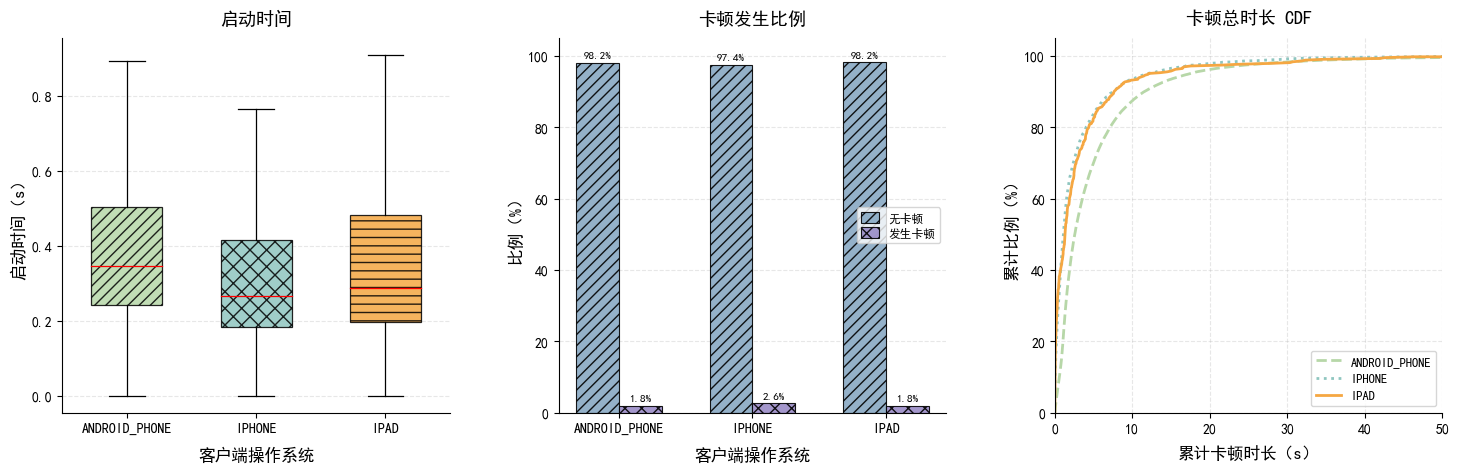

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 读取 playback.txt
# ============================================================

file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# ============================================================
# 2. 提取字段
# ============================================================

data = pd.DataFrame({
    'client_os': df.iloc[:, 2].astype(str),

    # 启动时间，单位 ms
    'startup_time': pd.to_numeric(
        df.iloc[:, 16],
        errors='coerce'
    ),

    # 卡顿次数
    'block_count': pd.to_numeric(
        df.iloc[:, 8],
        errors='coerce'
    ),

    # 卡顿总时长，单位 ms
    'block_duration': pd.to_numeric(
        df.iloc[:, 9],
        errors='coerce'
    )
})

# ============================================================
# 3. 数据清洗
# ============================================================

data = data[
    data['client_os'].isin(['ANDROID_PHONE', 'IPHONE', 'IPAD'])
].copy()

data = data.dropna()

data = data[
    (data['startup_time'] >= 0) &
    (data['block_count'] >= 0) &
    (data['block_duration'] >= 0)
].copy()

# ms → s
data['startup_time_s'] = data['startup_time'] / 1000
data['block_duration_s'] = data['block_duration'] / 1000

# 网络类型名称
network_labels = ['ANDROID_PHONE', 'IPHONE', 'IPAD']

# ============================================================
# 4. 输出基本统计结果
# ============================================================

print('=' * 60)
print('网络类型样本数量')
print('=' * 60)

print(data['client_os'].value_counts())

print('\n网络类型比例')
print(data['client_os'].value_counts(normalize=True))

print('\n' + '=' * 60)
print('播放体验统计')
print('=' * 60)

stats = data.groupby('client_os').agg(
    startup_mean=('startup_time_s', 'mean'),
    startup_median=('startup_time_s', 'median'),

    rebuff_count_mean=('block_count', 'mean'),
    rebuff_count_median=('block_count', 'median'),

    rebuff_duration_mean=('block_duration_s', 'mean'),
    rebuff_duration_median=('block_duration_s', 'median')
)

print(stats)

# ============================================================
# 5. 绘图参数
# ============================================================
network_labels = ['ANDROID_PHONE', 'IPHONE', 'IPAD']
display_labels = network_labels

# 与前面实验结果分析部分接近的配色
colors = [
    '#B7D7A8',
    '#8FC6C0',
    '#F5A742',
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]


hatches = [
    '///',
    'xx',
    '--',
    '/\\'
]

# ============================================================
# 创建三个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5.2)
)

# ============================================================
# 子图 1：启动时间
# ============================================================

startup_data = [
    data.loc[
        data['client_os'] == network,
        'startup_time_s'
    ].values
    for network in network_labels
]

bp = axes[0].boxplot(
    startup_data,
    labels=display_labels,
    showfliers=False,
    widths=0.55,
    patch_artist=True
)

# 设置箱线图样式
for i, box in enumerate(bp['boxes']):
    box.set(
        facecolor=colors[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.9,
        alpha=0.85
    )

for element in [
    'whiskers',
    'caps',
]:

    for item in bp[element]:
        item.set(
            color='black',
            linewidth=0.9
        )

for element in [
    'medians'
]:
    for item in bp[element]:
        item.set(
            color='red',
            linewidth=0.9
        )

axes[0].set_xlabel(
    '客户端操作系统',
    fontsize=12,
    labelpad=8
)

axes[0].set_ylabel(
    '启动时间（s）',
    fontsize=12
)

axes[0].set_title(
    '启动时间',
    fontsize=13,
    pad=10
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)

# ============================================================
# 子图 2：卡顿发生比例
# ============================================================

no_rebuffer_ratio = []
rebuffer_ratio = []

for network in network_labels:

    subset = data[
        data['client_os'] == network
    ]

    no_rebuffer = (
        subset['block_count'] == 0
    ).mean()

    rebuffer = (
        subset['block_count'] > 0
    ).mean()

    no_rebuffer_ratio.append(
        no_rebuffer * 100
    )

    rebuffer_ratio.append(
        rebuffer * 100
    )


x = np.arange(
    len(network_labels)
)

width = 0.32

no_rebuffer = np.array(
    no_rebuffer_ratio
)

rebuffer = np.array(
    rebuffer_ratio
)

bars1 = axes[1].bar(
    x - width / 2,
    no_rebuffer,
    width,
    label='无卡顿',
    color=colors[3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[0],
    alpha=0.9
)

bars2 = axes[1].bar(
    x + width / 2,
    rebuffer,
    width,
    label='发生卡顿',
    color=colors[4],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[1],
    alpha=0.9
)

# ============================================================
# 柱状图数值标签
# ============================================================

for bars in [
    bars1,
    bars2
]:

    for bar in bars:
        value = bar.get_height()

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    display_labels,
    fontsize=10
)

axes[1].set_xlabel(
    '客户端操作系统',
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel(
    '比例（%）',
    fontsize=12
)

axes[1].set_title(
    '卡顿发生比例',
    fontsize=13,
    pad=10
)

axes[1].set_ylim(
    0,
    105
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].legend(
    loc='center right',
    fontsize=8.5,
    frameon=True,
    ncol=1,
    handlelength=1.5,
    handleheight=1.0,
    columnspacing=0.8,
    labelspacing=0.3,
)

# ============================================================
# 子图 3：卡顿总时长 CDF
# ============================================================
linestyles = ['--', ':', '-']

for i, (network, label) in enumerate(
        zip(
            network_labels,
            display_labels
        )
):

    duration = data.loc[
        (data['client_os'] == network) &
        (data['block_duration_s'] > 0),
        'block_duration_s'
    ].sort_values()

    if len(duration) == 0:
        continue

    cdf = (
            np.arange(
                1,
                len(duration) + 1
            )
            / len(duration)
    )

    axes[2].plot(
        duration,
        cdf * 100,
        linewidth=2,
        label=label,
        color=colors[i],
        linestyle=linestyles[i],
    )

axes[2].set_xlabel(
    '累计卡顿时长（s）',
    fontsize=12,
    labelpad=8
)

axes[2].set_ylabel(
    '累计比例（%）',
    fontsize=12
)

axes[2].set_title(
    '卡顿总时长 CDF',
    fontsize=13,
    pad=10
)

axes[2].set_xlim(
    0,
    50
)

axes[2].set_ylim(
    0,
    105
)

axes[2].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[2].set_axisbelow(True)

axes[2].legend(
    fontsize=9,
    frameon=True,
    loc='lower right'
)

# ============================================================
# 统一设置三个子图
# ============================================================

for ax in axes:
    # 去除顶部、右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )

# ============================================================
# 调整布局
# ============================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.16,
    top=0.88,
    wspace=0.28
)

# ============================================================
# 保存
# ============================================================

plt.savefig(
    'client_os_playback_experience.svg',
    bbox_inches='tight'
)

plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 读取 playback.txt
# ============================================================

file_path = 'data/playback.txt'

df = pd.read_csv(
    file_path,
    sep='\t',
    header=None
)

# ============================================================
# 2. 提取字段
# ============================================================

data = pd.DataFrame({
    'isp': df.iloc[:, 21].astype(str),

    # 启动时间，单位 ms
    'startup_time': pd.to_numeric(
        df.iloc[:, 16],
        errors='coerce'
    ),

    # 卡顿次数
    'block_count': pd.to_numeric(
        df.iloc[:, 8],
        errors='coerce'
    ),

    # 卡顿总时长，单位 ms
    'block_duration': pd.to_numeric(
        df.iloc[:, 9],
        errors='coerce'
    )
})

# ============================================================
# 3. 数据清洗
# ============================================================
isp_label = data['isp'].value_counts().head(5).index

In [15]:
print(isp_label)
print(isp_label.head(5).index)

isp
f6f77a498c2b2c7e04ead59fbeec5128    998923
68d982a1cc0358bd08c0d6c7db88c238    835131
8604270694837d14d85ca6db182c7375    732516
d0d357dbee6fda491c1f8d8858c459c4    288267
e25628982fa2a335197fedb0cecc1654     70038
983a43c1d1f3d634609bb858faf66052     28812
d8d135f8d7975d760679dd0681193231     14409
1a16530bfabf83d0177947f3cbaec652      5534
696b031073e74bf2cb98e5ef201d4aa3        82
2b2255b92b7f816a68d590042b92072f        77
3ce81858dbce80c46ab03c253096bb97        13
Name: count, dtype: int64
Index(['f6f77a498c2b2c7e04ead59fbeec5128', '68d982a1cc0358bd08c0d6c7db88c238',
       '8604270694837d14d85ca6db182c7375', 'd0d357dbee6fda491c1f8d8858c459c4',
       'e25628982fa2a335197fedb0cecc1654'],
      dtype='object', name='isp')


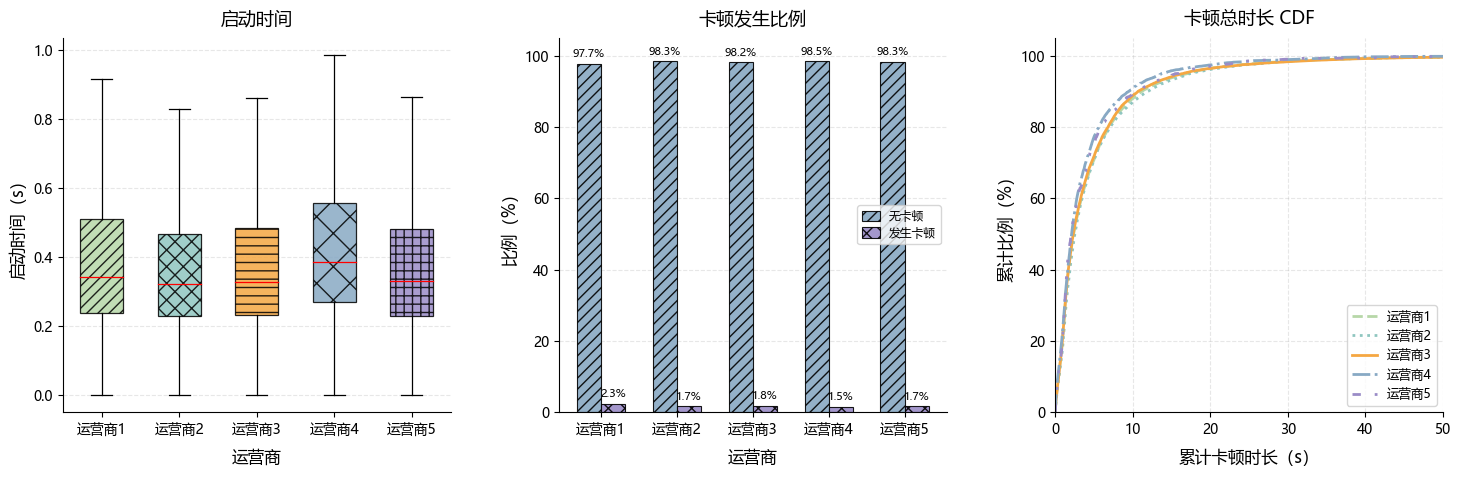

In [39]:
data = data[
    data['isp'].isin(isp_label)
].copy()
# print(data)
data = data.dropna()

data = data[
    (data['startup_time'] >= 0) &
    (data['block_count'] >= 0) &
    (data['block_duration'] >= 0)
].copy()

# ms → s
data['startup_time_s'] = data['startup_time'] / 1000
data['block_duration_s'] = data['block_duration'] / 1000

# 网络类型名称
network_labels = isp_label

# ============================================================
# 4. 输出基本统计结果
# ============================================================

print('=' * 60)
print('网络类型样本数量')
print('=' * 60)

print(data['isp'].value_counts())

print('\n网络类型比例')
print(data['isp'].value_counts(normalize=True))

print('\n' + '=' * 60)
print('播放体验统计')
print('=' * 60)

stats = data.groupby('isp').agg(
    startup_mean=('startup_time_s', 'mean'),
    startup_median=('startup_time_s', 'median'),

    rebuff_count_mean=('block_count', 'mean'),
    rebuff_count_median=('block_count', 'median'),

    rebuff_duration_mean=('block_duration_s', 'mean'),
    rebuff_duration_median=('block_duration_s', 'median')
)

print(stats)

# ============================================================
# 5. 绘图参数
# ============================================================
network_labels = ['运营商1', '运营商2', '运营商3', '运营商4', '运营商5']
display_labels = network_labels

# 与前面实验结果分析部分接近的配色
colors = [
    '#B7D7A8',
    '#8FC6C0',
    '#F5A742',
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]


hatches = [
    '///',
    'xx',
    '--',
    '/\\',
    '++'
]

# ============================================================
# 创建三个子图
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5.2)
)

# ============================================================
# 子图 1：启动时间
# ============================================================

startup_data = [
    data.loc[
        data['isp'] == network,
        'startup_time_s'
    ].values
    for network in isp_label
]

bp = axes[0].boxplot(
    startup_data,
    labels=display_labels,
    showfliers=False,
    widths=0.55,
    patch_artist=True
)

# 设置箱线图样式
for i, box in enumerate(bp['boxes']):
    box.set(
        facecolor=colors[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.9,
        alpha=0.85
    )

for element in [
    'whiskers',
    'caps',
]:

    for item in bp[element]:
        item.set(
            color='black',
            linewidth=0.9
        )

for element in [
    'medians'
]:
    for item in bp[element]:
        item.set(
            color='red',
            linewidth=0.9
        )

axes[0].set_xlabel(
    '运营商',
    fontsize=12,
    labelpad=8
)

axes[0].set_ylabel(
    '启动时间（s）',
    fontsize=12
)

axes[0].set_title(
    '启动时间',
    fontsize=13,
    pad=10
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)


# ============================================================
# 子图 2：卡顿发生比例
# ============================================================

no_rebuffer_ratio = []
rebuffer_ratio = []

for network in isp_label:

    subset = data[
        data['isp'] == network
    ]
    # print(subset)
    no_rebuffer = (
        subset['block_count'] == 0
    ).mean()

    rebuffer = (
        subset['block_count'] > 0
    ).mean()

    no_rebuffer_ratio.append(
        no_rebuffer * 100
    )

    rebuffer_ratio.append(
        rebuffer * 100
    )


x = np.arange(
    len(network_labels)
)

width = 0.32

no_rebuffer = np.array(
    no_rebuffer_ratio
)

rebuffer = np.array(
    rebuffer_ratio
)

bars1 = axes[1].bar(
    x - width / 2,
    no_rebuffer,
    width,
    label='无卡顿',
    color=colors[3],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[0],
    alpha=0.9
)

bars2 = axes[1].bar(
    x + width / 2,
    rebuffer,
    width,
    label='发生卡顿',
    color=colors[4],
    edgecolor='black',
    linewidth=0.8,
    hatch=hatches[1],
    alpha=0.9
)

# ============================================================
# 柱状图数值标签
# ============================================================

for bars in [
    bars1,
    bars2
]:

    for bar in bars:
        value = bar.get_height()

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f'{value:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    display_labels,
    fontsize=10
)

axes[1].set_xlabel(
    '运营商',
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel(
    '比例（%）',
    fontsize=12
)

axes[1].set_title(
    '卡顿发生比例',
    fontsize=13,
    pad=10
)

axes[1].set_ylim(
    0,
    105
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].legend(
    loc='center right',
    fontsize=8.5,
    frameon=True,
    ncol=1,
    handlelength=1.5,
    handleheight=1.0,
    columnspacing=0.8,
    labelspacing=0.3,
)

# ============================================================
# 子图 3：卡顿总时长 CDF
# ============================================================
linestyles = ['--', ':', '-', '-.', (0, (3,5,1,5,1,5))]

for i, (network, label) in enumerate(
        zip(
            isp_label,
            display_labels
        )
):

    duration = data.loc[
        (data['isp'] == network) &
        (data['block_duration_s'] > 0),
        'block_duration_s'
    ].sort_values()
    # print(duration)
    if len(duration) == 0:
        continue

    cdf = (
            np.arange(
                1,
                len(duration) + 1
            )
            / len(duration)
    )

    axes[2].plot(
        duration,
        cdf * 100,
        linewidth=2,
        label=label,
        color=colors[i],
        linestyle=linestyles[i],
    )

axes[2].set_xlabel(
    '累计卡顿时长（s）',
    fontsize=12,
    labelpad=8
)

axes[2].set_ylabel(
    '累计比例（%）',
    fontsize=12
)

axes[2].set_title(
    '卡顿总时长 CDF',
    fontsize=13,
    pad=10
)

axes[2].set_xlim(
    0,
    50
)

axes[2].set_ylim(
    0,
    105
)

axes[2].grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

axes[2].set_axisbelow(True)

axes[2].legend(
    fontsize=9,
    frameon=True,
    loc='lower right'
)

# ============================================================
# 统一设置三个子图
# ============================================================

for ax in axes:
    # 去除顶部、右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 坐标轴字体
    ax.tick_params(
        axis='both',
        labelsize=10
    )

# ============================================================
# 调整布局
# ============================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.16,
    top=0.88,
    wspace=0.28
)

# ============================================================
# 保存
# ============================================================

plt.savefig(
    'isp_playback_experience.svg',
    bbox_inches='tight'
)

plt.show()